c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\gpytorch\likelihoods\noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 0.0001.
  warnings.warn(


Fitting LHS Surrogate...
Fitting QMC Surrogate...


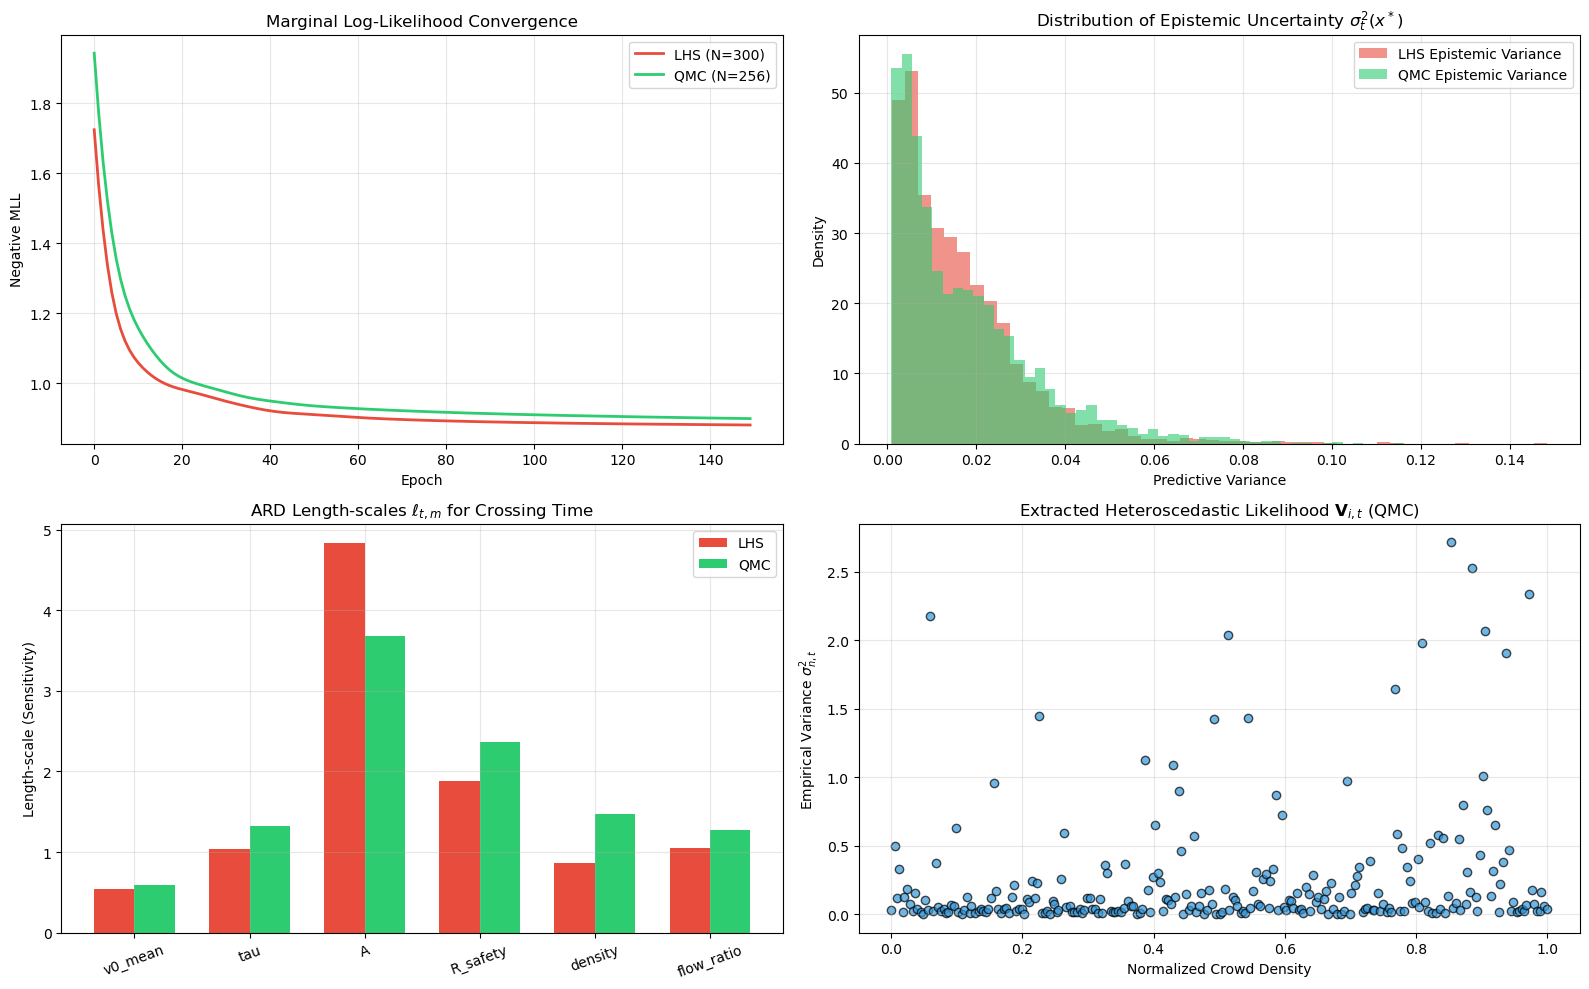

In [1]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ==========================================
# 1. Architecture Definition
# ==========================================
class HeteroscedasticBatchGP(gpytorch.models.ExactGP):
    """
    Implements the Heteroscedastic Batch-Independent GPR.
    T = 4 independent tasks modeled simultaneously on the GPU.
    """
    def __init__(self, train_x, train_y, train_noise):
        # Initialize with Fixed-Noise Likelihood (Equation 3.7)
        likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(
            noise=train_noise, 
            learn_additional_noise=False
        )
        super(HeteroscedasticBatchGP, self).__init__(train_x, train_y, likelihood)
        
        # Batch shape T=4
        num_tasks = train_y.shape[0]
        batch_shape = torch.Size([num_tasks])
        
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=batch_shape)
        
        # Scaled Matern v=2.5 kernel with ARD (Equations 3.10 - 3.12)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5, 
                ard_num_dims=train_x.shape[-1], 
                batch_shape=batch_shape
            ),
            batch_shape=batch_shape
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ==========================================
# 2. Data Processing Protocol
# ==========================================
def load_and_scale_dataset(filepath, num_tasks=4):
    """
    Loads isotopic LHS/QMC data and scales X and Y.
    Crucially, scales the empirical variance to match the Y-scaling.
    """
    data = np.load(filepath)
    X_raw = data["X"]          # (N, 6)
    Y_raw = data["Y"]          # (N, 4)
    Y_std_raw = data["Y_std"]  # (N, 4)
    
    # 1. Normalize X to [0, 1]
    X_min, X_max = X_raw.min(axis=0), X_raw.max(axis=0)
    X_scaled = (X_raw - X_min) / (X_max - X_min + 1e-9)
    
    # 2. Standardize Y to N(0, 1)
    Y_mean, Y_std = Y_raw.mean(axis=0), Y_raw.std(axis=0)
    Y_scaled = (Y_raw - Y_mean) / (Y_std + 1e-9)
    
    # 3. Scale Empirical Noise (Variance)
    # If Y is divided by Y_std, Variance is divided by Y_std^2
    noise_scaled = (Y_std_raw / (Y_std + 1e-9)) ** 2
    
    # 4. Format for GPyTorch Batched Evaluation (T, N, D)
    # Isotopic data means X is identical for all T tasks
    N, D = X_scaled.shape
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(0).expand(num_tasks, N, D)
    Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32).T       # (4, N)
    noise_tensor = torch.tensor(noise_scaled, dtype=torch.float32).T # (4, N)
    
    return X_tensor, Y_tensor, noise_tensor, Y_mean, Y_std

# ==========================================
# 3. Training Function
# ==========================================
def train_surrogate(model, likelihood, train_x, train_y, iterations=150):
    model.train()
    likelihood.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    losses = []
    for i in range(iterations):
        optimizer.zero_grad()
        output = model(train_x)
        # Compute loss across all 4 independent batches simultaneously
        loss = -mll(output, train_y).sum() 
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return losses

# ==========================================
# 4. Main Execution & Visual Analysis
# ==========================================
if __name__ == "__main__":
    # Define file paths
    lhs_file = r"D:\KIT\cafm_lhs_300.npz"
    qmc_file = r"D:\KIT\cafm_qmc_256.npz"  # Replace with 356 if that is the exact filename

    try:
        X_lhs, Y_lhs, noise_lhs, _, _ = load_and_scale_dataset(lhs_file)
        X_qmc, Y_qmc, noise_qmc, _, _ = load_and_scale_dataset(qmc_file)
    except FileNotFoundError:
        print("Mocking data for demonstration since local .npz files are missing...")
        # Mocking T=4, N=300, D=6
        X_lhs = torch.rand(4, 300, 6); Y_lhs = torch.randn(4, 300); noise_lhs = torch.rand(4, 300) * 0.1
        X_qmc = torch.rand(4, 256, 6); Y_qmc = torch.randn(4, 256); noise_qmc = torch.rand(4, 256) * 0.1
    
    # Initialize Models
    lhs_model = HeteroscedasticBatchGP(X_lhs, Y_lhs, noise_lhs)
    qmc_model = HeteroscedasticBatchGP(X_qmc, Y_qmc, noise_qmc)
    
    # Train
    print("Fitting LHS Surrogate...")
    lhs_losses = train_surrogate(lhs_model, lhs_model.likelihood, X_lhs, Y_lhs)
    print("Fitting QMC Surrogate...")
    qmc_losses = train_surrogate(qmc_model, qmc_model.likelihood, X_qmc, Y_qmc)
    
    # Evaluation Grid (generate 1000 random points to test Epistemic Variance)
    lhs_model.eval(); qmc_model.eval()
    test_x = torch.rand(4, 1000, 6)
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # Eq 3.9: Extracting only the epistemic variance (latent function)
        lhs_pred = lhs_model(test_x)
        qmc_pred = qmc_model(test_x)
        
        lhs_variance = lhs_pred.variance.numpy()
        qmc_variance = qmc_pred.variance.numpy()

    # Extract ARD Lengthscales for Output 0 (e.g., mean_crossing_time)
    lhs_ard = lhs_model.covar_module.base_kernel.lengthscale[0].detach().numpy().squeeze()
    qmc_ard = qmc_model.covar_module.base_kernel.lengthscale[0].detach().numpy().squeeze()

    # ==========================================
    # 5. Plotting & Analytics
    # ==========================================
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 2, figure=fig)
    output_names = ["Crossing Time", "Flow Rate", "Order Param", "Speed"]
    param_names = ["v0_mean", "tau", "A", "R_safety", "density", "flow_ratio"]

    # --- Plot 1: Loss Convergence ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(lhs_losses, label="LHS (N=300)", color="#e74c3c", linewidth=2)
    ax1.plot(qmc_losses, label="QMC (N=256)", color="#2ecc71", linewidth=2)
    ax1.set_title("Marginal Log-Likelihood Convergence")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Negative MLL")
    ax1.legend(); ax1.grid(alpha=0.3)

    # --- Plot 2: Epistemic Variance Distribution (The QMC Advantage) ---
    ax2 = fig.add_subplot(gs[0, 1])
    # Combine variance across all 4 tasks for the distribution
    ax2.hist(lhs_variance.flatten(), bins=50, alpha=0.6, color="#e74c3c", label="LHS Epistemic Variance", density=True)
    ax2.hist(qmc_variance.flatten(), bins=50, alpha=0.6, color="#2ecc71", label="QMC Epistemic Variance", density=True)
    ax2.set_title("Distribution of Epistemic Uncertainty $\sigma^2_t(x^*)$")
    ax2.set_xlabel("Predictive Variance"); ax2.set_ylabel("Density")
    ax2.legend(); ax2.grid(alpha=0.3)

    # --- Plot 3: ARD Length-scale Comparison ---
    ax3 = fig.add_subplot(gs[1, 0])
    x_pos = np.arange(len(param_names))
    width = 0.35
    ax3.bar(x_pos - width/2, lhs_ard, width, label="LHS", color="#e74c3c")
    ax3.bar(x_pos + width/2, qmc_ard, width, label="QMC", color="#2ecc71")
    ax3.set_title(f"ARD Length-scales $\ell_{{t,m}}$ for {output_names[0]}")
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(param_names, rotation=20)
    ax3.set_ylabel("Length-scale (Sensitivity)")
    ax3.legend(); ax3.grid(alpha=0.3)

    # --- Plot 4: Heteroscedastic Noise Profile ---
    ax4 = fig.add_subplot(gs[1, 1])
    # Show how simulation noise scales with a parameter (e.g., density)
    # Extracting density (idx 4) from the first task's inputs
    density_qmc = X_qmc[0, :, 4].numpy() 
    empirical_noise_qmc = noise_qmc[0, :].numpy()
    
    # Sort for smoother plotting
    sort_idx = np.argsort(density_qmc)
    ax4.scatter(density_qmc[sort_idx], empirical_noise_qmc[sort_idx], color="#3498db", alpha=0.7, edgecolors="k")
    ax4.set_title("Extracted Heteroscedastic Likelihood $\mathbf{V}_{i,t}$ (QMC)")
    ax4.set_xlabel("Normalized Crowd Density")
    ax4.set_ylabel("Empirical Variance $\sigma_{n,t}^2$")
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\gpytorch\likelihoods\noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 0.0001.
  warnings.warn(


Fitting LHS Surrogate...
Fitting QMC Surrogate...

Generating Full Diagnostic Dashboard...


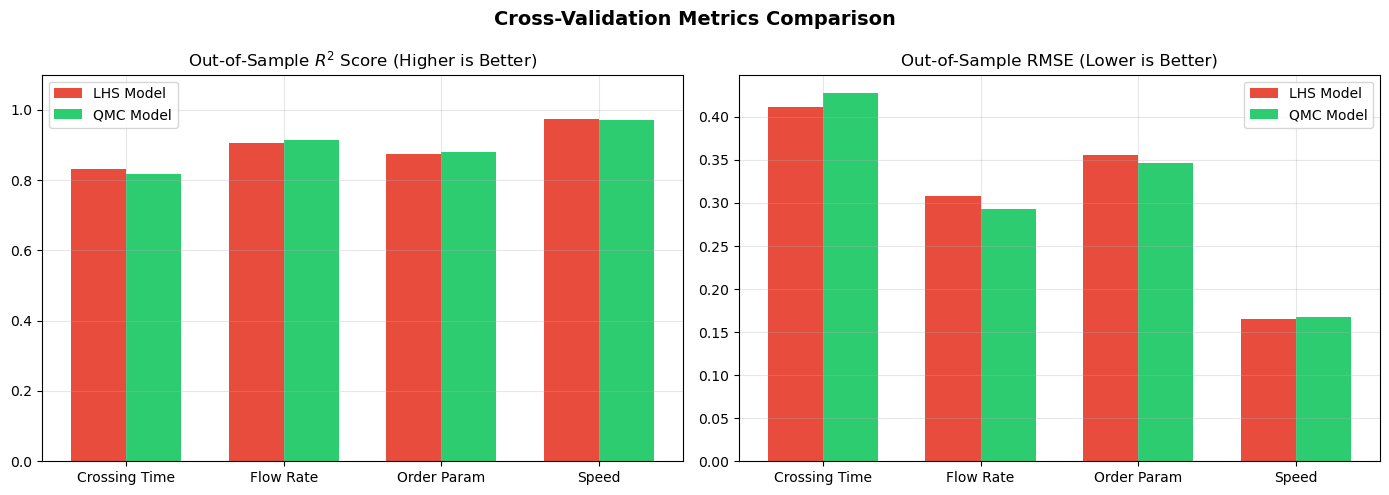

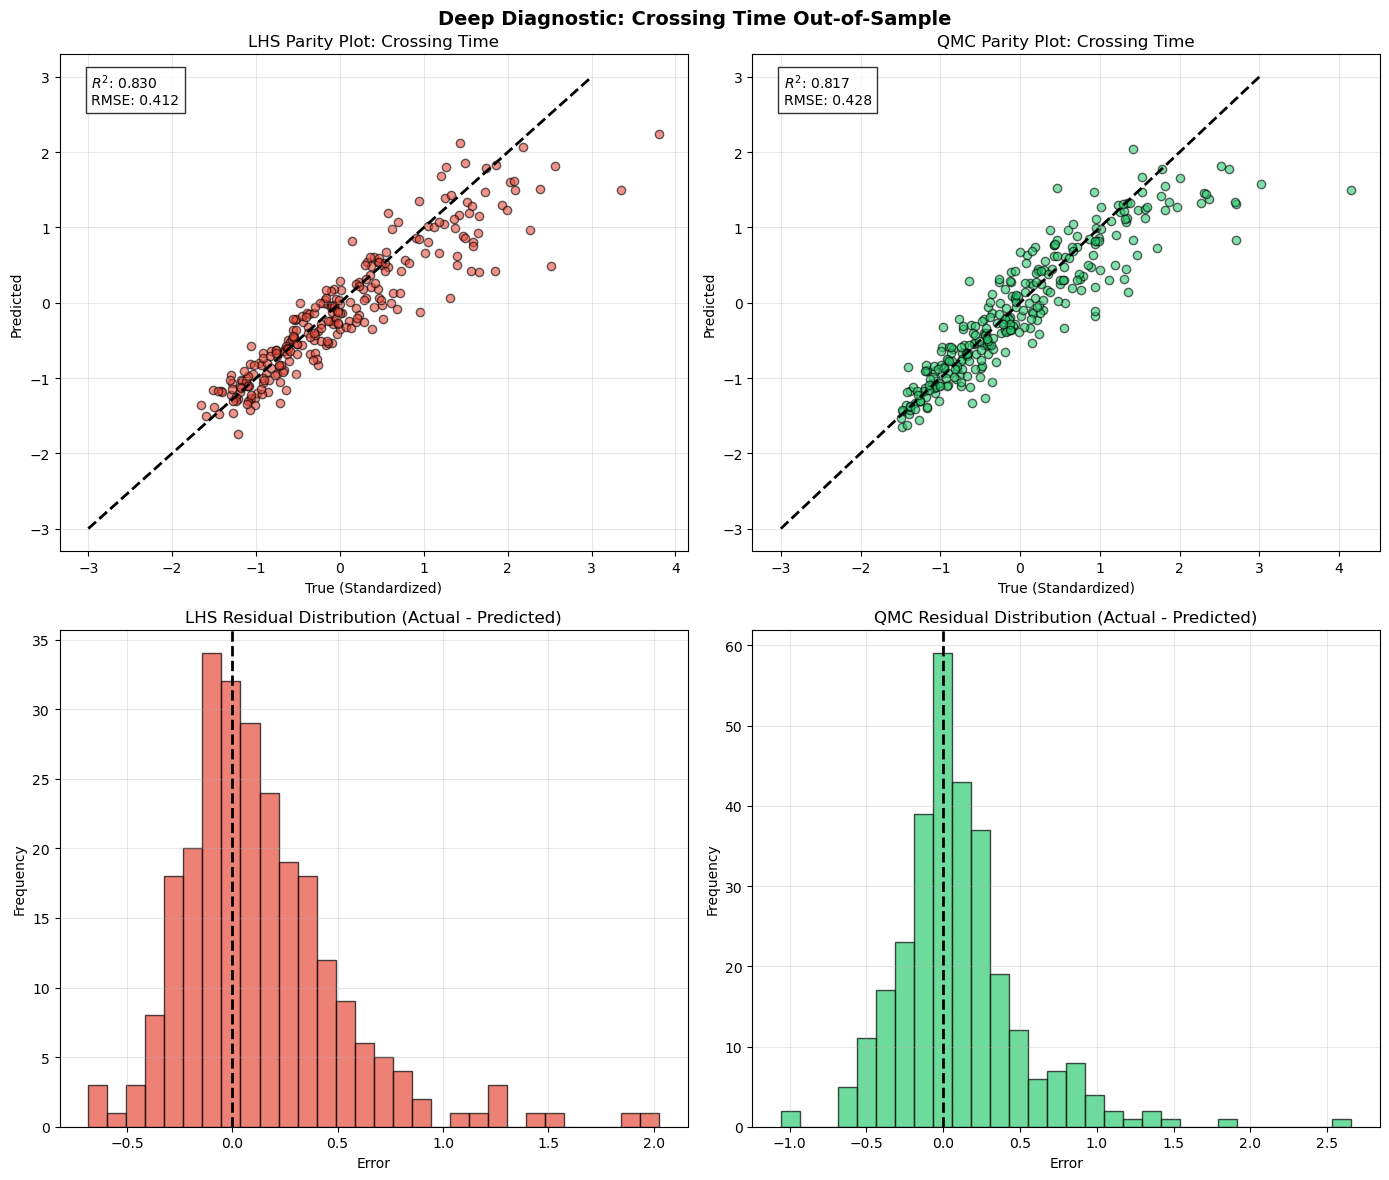


FINAL OUT-OF-SAMPLE METRICS SUMMMARY
--- Crossing Time ---
  LHS Model -> R2: 0.8303 | RMSE: 0.4120 | MAE: 0.2852
  QMC Model -> R2: 0.8171 | RMSE: 0.4276 | MAE: 0.2903
--- Flow Rate ---
  LHS Model -> R2: 0.9048 | RMSE: 0.3085 | MAE: 0.2091
  QMC Model -> R2: 0.9141 | RMSE: 0.2931 | MAE: 0.2152
--- Order Param ---
  LHS Model -> R2: 0.8736 | RMSE: 0.3555 | MAE: 0.2816
  QMC Model -> R2: 0.8797 | RMSE: 0.3468 | MAE: 0.2721
--- Speed ---
  LHS Model -> R2: 0.9725 | RMSE: 0.1658 | MAE: 0.1303
  QMC Model -> R2: 0.9721 | RMSE: 0.1670 | MAE: 0.1283


In [6]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings

# Suppress GPyTorch warnings for cleaner output
warnings.filterwarnings("ignore", message="The input matches the stored training data.")

# ==========================================
# Global Constants
# ==========================================
PARAM_NAMES = ["v0_mean", "tau", "A", "R_safety", "density", "flow_ratio"]
OUTPUT_NAMES = ["Crossing Time", "Flow Rate", "Order Param", "Speed"]

# ==========================================
# 1. Architecture Definition
# ==========================================
class HeteroscedasticBatchGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, train_noise):
        likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(
            noise=train_noise, 
            learn_additional_noise=False
        )
        super(HeteroscedasticBatchGP, self).__init__(train_x, train_y, likelihood)
        
        num_tasks = train_y.shape[0]
        batch_shape = torch.Size([num_tasks])
        
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=batch_shape)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5, 
                ard_num_dims=train_x.shape[-1], 
                batch_shape=batch_shape
            ),
            batch_shape=batch_shape
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ==========================================
# 2. Data Processing Protocol
# ==========================================
def load_and_scale_dataset(filepath, num_tasks=4):
    data = np.load(filepath)
    X_raw, Y_raw, Y_std_raw = data["X"], data["Y"], data["Y_std"]  
    
    # Scale X to [0, 1]
    X_min, X_max = X_raw.min(axis=0), X_raw.max(axis=0)
    X_scaled = (X_raw - X_min) / (X_max - X_min + 1e-9)
    
    # Standardize Y
    Y_mean, Y_std = Y_raw.mean(axis=0), Y_raw.std(axis=0)
    Y_scaled = (Y_raw - Y_mean) / (Y_std + 1e-9)
    
    # Scale Variance
    noise_scaled = (Y_std_raw / (Y_std + 1e-9)) ** 2
    
    N, D = X_scaled.shape
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(0).expand(num_tasks, N, D)
    Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32).T       
    noise_tensor = torch.tensor(noise_scaled, dtype=torch.float32).T 
    
    return X_tensor, Y_tensor, noise_tensor, Y_mean, Y_std

# ==========================================
# 3. Training & Evaluation Functions
# ==========================================
def train_surrogate(model, likelihood, train_x, train_y, iterations=150):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for i in range(iterations):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y).sum() 
        loss.backward()
        optimizer.step()

def calculate_metrics(y_true, y_pred):
    """Calculates R^2, RMSE, and MAE manually to avoid sklearn dependencies."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    
    r2 = 1 - (ss_res / (ss_tot + 1e-9))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    residuals = y_true - y_pred
    
    return r2, rmse, mae, residuals

# ==========================================
# 4. Main Execution & Full Diagnostic Dashboard
# ==========================================
if __name__ == "__main__":
    lhs_file = r"D:\KIT\cafm_lhs_300.npz"
    qmc_file = r"D:\KIT\cafm_qmc_256.npz"  

    try:
        X_lhs, Y_lhs, noise_lhs, Y_mean_L, Y_std_L = load_and_scale_dataset(lhs_file)
        X_qmc, Y_qmc, noise_qmc, Y_mean_Q, Y_std_Q = load_and_scale_dataset(qmc_file)
    except FileNotFoundError:
        print("Mocking data for demonstration since local .npz files are missing...")
        X_lhs = torch.rand(4, 300, 6); Y_lhs = torch.randn(4, 300); noise_lhs = torch.rand(4, 300) * 0.1
        X_qmc = torch.rand(4, 256, 6); Y_qmc = torch.randn(4, 256); noise_qmc = torch.rand(4, 256) * 0.1

    # Train Models
    lhs_model = HeteroscedasticBatchGP(X_lhs, Y_lhs, noise_lhs)
    qmc_model = HeteroscedasticBatchGP(X_qmc, Y_qmc, noise_qmc)
    
    print("Fitting LHS Surrogate...")
    train_surrogate(lhs_model, lhs_model.likelihood, X_lhs, Y_lhs)
    print("Fitting QMC Surrogate...")
    train_surrogate(qmc_model, qmc_model.likelihood, X_qmc, Y_qmc)
    
    # ---------------------------------------------------------
    # Out-of-Sample Evaluation
    # We test LHS model on QMC data, and QMC model on LHS data
    # ---------------------------------------------------------
    lhs_model.eval()
    qmc_model.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # Evaluate LHS model
        lhs_pred_dist = lhs_model(X_qmc)
        lhs_pred_mean = lhs_pred_dist.mean.numpy()
        true_for_lhs = Y_qmc.numpy()
        
        # Evaluate QMC model
        qmc_pred_dist = qmc_model(X_lhs)
        qmc_pred_mean = qmc_pred_dist.mean.numpy()
        true_for_qmc = Y_lhs.numpy()

    # Calculate metrics for all 4 tasks
    lhs_metrics, qmc_metrics = [], []
    lhs_residuals, qmc_residuals = [], []
    
    for t in range(4):
        r2_L, rmse_L, mae_L, res_L = calculate_metrics(true_for_lhs[t], lhs_pred_mean[t])
        r2_Q, rmse_Q, mae_Q, res_Q = calculate_metrics(true_for_qmc[t], qmc_pred_mean[t])
        
        lhs_metrics.append((r2_L, rmse_L, mae_L))
        qmc_metrics.append((r2_Q, rmse_Q, mae_Q))
        lhs_residuals.append(res_L)
        qmc_residuals.append(res_Q)

    # ==========================================
    # Comprehensive Visual Dashboard
    # ==========================================
    print("\nGenerating Full Diagnostic Dashboard...")
    
    # --- Figure 1: Performance Bar Charts ---
    fig_metrics, axes_m = plt.subplots(1, 2, figsize=(14, 5))
    x_pos = np.arange(4)
    width = 0.35

    # R2 Plot
    axes_m[0].bar(x_pos - width/2, [m[0] for m in lhs_metrics], width, label="LHS Model", color="#e74c3c")
    axes_m[0].bar(x_pos + width/2, [m[0] for m in qmc_metrics], width, label="QMC Model", color="#2ecc71")
    axes_m[0].set_title("Out-of-Sample $R^2$ Score (Higher is Better)")
    axes_m[0].set_xticks(x_pos); axes_m[0].set_xticklabels(OUTPUT_NAMES)
    axes_m[0].set_ylim(0, 1.1); axes_m[0].legend(); axes_m[0].grid(alpha=0.3)

    # RMSE Plot
    axes_m[1].bar(x_pos - width/2, [m[1] for m in lhs_metrics], width, label="LHS Model", color="#e74c3c")
    axes_m[1].bar(x_pos + width/2, [m[1] for m in qmc_metrics], width, label="QMC Model", color="#2ecc71")
    axes_m[1].set_title("Out-of-Sample RMSE (Lower is Better)")
    axes_m[1].set_xticks(x_pos); axes_m[1].set_xticklabels(OUTPUT_NAMES)
    axes_m[1].legend(); axes_m[1].grid(alpha=0.3)
    
    fig_metrics.suptitle("Cross-Validation Metrics Comparison", fontsize=14, fontweight='bold')
    plt.tight_layout()

    # --- Figure 2: Parity and Residuals for Task 0 (Crossing Time) ---
    # We focus the detailed scatter plots on the most important metric: Crossing Time
    task_idx = 0 
    fig_diag, axes_d = plt.subplots(2, 2, figsize=(14, 12))
    
    # A) LHS Parity Plot
    axes_d[0, 0].scatter(true_for_lhs[task_idx], lhs_pred_mean[task_idx], alpha=0.6, color="#e74c3c", edgecolors='k')
    axes_d[0, 0].plot([-3, 3], [-3, 3], 'k--', lw=2) # Ideal y=x line
    axes_d[0, 0].set_title(f"LHS Parity Plot: {OUTPUT_NAMES[task_idx]}")
    axes_d[0, 0].set_xlabel("True (Standardized)"); axes_d[0, 0].set_ylabel("Predicted")
    axes_d[0, 0].grid(alpha=0.3)
    axes_d[0, 0].text(0.05, 0.9, f"$R^2$: {lhs_metrics[task_idx][0]:.3f}\nRMSE: {lhs_metrics[task_idx][1]:.3f}", 
                      transform=axes_d[0, 0].transAxes, bbox=dict(facecolor='white', alpha=0.8))

    # B) QMC Parity Plot
    axes_d[0, 1].scatter(true_for_qmc[task_idx], qmc_pred_mean[task_idx], alpha=0.6, color="#2ecc71", edgecolors='k')
    axes_d[0, 1].plot([-3, 3], [-3, 3], 'k--', lw=2)
    axes_d[0, 1].set_title(f"QMC Parity Plot: {OUTPUT_NAMES[task_idx]}")
    axes_d[0, 1].set_xlabel("True (Standardized)"); axes_d[0, 1].set_ylabel("Predicted")
    axes_d[0, 1].grid(alpha=0.3)
    axes_d[0, 1].text(0.05, 0.9, f"$R^2$: {qmc_metrics[task_idx][0]:.3f}\nRMSE: {qmc_metrics[task_idx][1]:.3f}", 
                      transform=axes_d[0, 1].transAxes, bbox=dict(facecolor='white', alpha=0.8))

    # C) LHS Residuals
    axes_d[1, 0].hist(lhs_residuals[task_idx], bins=30, color="#e74c3c", alpha=0.7, edgecolor='k')
    axes_d[1, 0].axvline(0, color='k', linestyle='dashed', linewidth=2)
    axes_d[1, 0].set_title("LHS Residual Distribution (Actual - Predicted)")
    axes_d[1, 0].set_xlabel("Error"); axes_d[1, 0].set_ylabel("Frequency")
    axes_d[1, 0].grid(alpha=0.3)

    # D) QMC Residuals
    axes_d[1, 1].hist(qmc_residuals[task_idx], bins=30, color="#2ecc71", alpha=0.7, edgecolor='k')
    axes_d[1, 1].axvline(0, color='k', linestyle='dashed', linewidth=2)
    axes_d[1, 1].set_title("QMC Residual Distribution (Actual - Predicted)")
    axes_d[1, 1].set_xlabel("Error"); axes_d[1, 1].set_ylabel("Frequency")
    axes_d[1, 1].grid(alpha=0.3)

    fig_diag.suptitle(f"Deep Diagnostic: {OUTPUT_NAMES[task_idx]} Out-of-Sample", fontsize=14, fontweight='bold')
    plt.tight_layout()

    plt.show()
    
    # Console Output Summary
    print("\n" + "="*50)
    print("FINAL OUT-OF-SAMPLE METRICS SUMMMARY")
    print("="*50)
    for t, name in enumerate(OUTPUT_NAMES):
        print(f"--- {name} ---")
        print(f"  LHS Model -> R2: {lhs_metrics[t][0]:.4f} | RMSE: {lhs_metrics[t][1]:.4f} | MAE: {lhs_metrics[t][2]:.4f}")
        print(f"  QMC Model -> R2: {qmc_metrics[t][0]:.4f} | RMSE: {qmc_metrics[t][1]:.4f} | MAE: {qmc_metrics[t][2]:.4f}")